In [1]:
from zfish._io import import16chFlt, import12chFlt
from zfish.local_path import *
import os

import numpy as np
import matplotlib.pyplot as plt
from zfish.utils import *

code_id = "5010 - Annual Report"
loc = os.path.join(figpath, code_id)
os.makedirs(loc, exist_ok=True)

# Linear Track Example Behavior

In [9]:
res = import16chFlt(r"D:\EnData\dat\10187\S2\res.16chFlt")
idx = np.where((res['behav_time'] >= 2520) & (res['behav_time'] <= 2590))[0]
for k in res.keys():
    res[k] = res[k][idx]
res['behav_pos_y'] *= 2

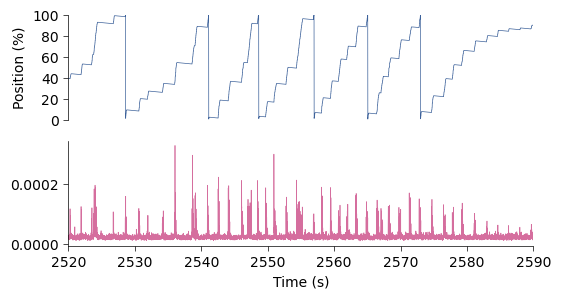

In [17]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(6, 3))
ax1 = Clear_Axes(axes[0], close_spines = ['top', 'right', 'bottom'], ifyticks=True)
ax2 = Clear_Axes(axes[1], close_spines = ['top', 'right'], ifxticks=True, ifyticks=True)
ax1.plot(res['behav_time'], res['behav_pos_y'], linewidth=0.5, color = ChannelColors[1])
ax2.plot(res['behav_time'], (res['fltCh0']+res['fltCh1'])/2, linewidth=0.5, color = ChannelColors[0])
ax1.set_xlim(2520, 2590)
ax2.set_xlim(2520, 2590)
ax2.set_xlabel("Time (s)")
ax1.set_ylabel("Position (%)")
ax1.set_yticks(np.linspace(0, 100, 6))
ax1.set_ylim(0, 100)
plt.savefig(os.path.join(loc, f"Example Swim Signal on Linear Track.png"), dpi=300)
plt.savefig(os.path.join(loc, f"Example Swim Signal on Linear Track.svg"), dpi=300)
plt.show()

# 2D Open Field

In [12]:
res = import16chFlt(r"D:\EnData\Open Field\10068\session 4\res.16chFlt", nchannel=16)
idx = np.where(
    (res['behav_time'] >= 5) & 
    (res['behav_time'] <= 3000) & 
    (res['behav_pos_x'] > 0) & 
    (res['behav_pos_y'] > 0) &
    (res['behav_pos_x'] < 100) & 
    (res['behav_pos_y'] < 100)  
)[0]
for k in res.keys():
    res[k] = res[k][idx]
x = res['behav_pos_x']
y = res['behav_pos_y']

NameError: name 'x' is not defined

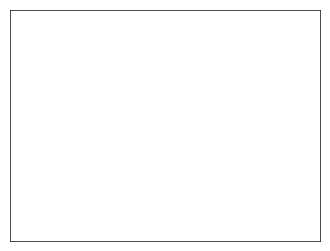

In [11]:
fig = plt.figure(figsize=(4, 3))
ax = Clear_Axes(fig.add_subplot(111), close_spines = [])

dx = np.diff(x)
dy = np.diff(y)
speed = np.append(np.sqrt(dx**2 + dy**2), 0)
speed_thre = np.percentile(speed, 99.95)
idx = np.arange(0, len(speed), 2000)
print(idx.shape[0])
ax.plot(x, y, linewidth=0.5, color = "lightgray",zorder=0)
ax.scatter(
    x[idx], 
    y[idx], 
    c = res['behav_time'][idx], 
    s=8, 
    cmap='viridis',
    edgecolor=None,
    linewidth=0,
    zorder=1,
    vmin=0,
    vmax=3000
)
ax.set_aspect('equal', adjustable='box')
cbar = plt.colorbar(ax.collections[0], ax=ax)
cbar.set_label("Time (s)")
plt.savefig(os.path.join(loc, f"Example Swim Trajectory on Open Field.png"), dpi=300)
plt.savefig(os.path.join(loc, f"Example Swim Trajectory on Open Field.svg"), dpi=300)
plt.show()

In [10]:

smoothed_dx = np.convolve(dx, np.ones(200)/200, mode='same')
smoothed_dy = np.convolve(dy, np.ones(200)/200, mode='same')

heading = np.arctan2(smoothed_dy, smoothed_dx)
no_verti_horiz = np.where(
    (np.abs(heading - np.pi) > 1e-3) &
    (np.abs(heading + np.pi) > 1e-3) &
    (np.abs(heading) > 1e-3)
)[0]
time_idx = np.where(
    (res['behav_time'][:-1] >= 940) & 
    (res['behav_time'][:-1] <= 945)
    #(np.abs(heading - np.pi) > 1e-3) &
    #(np.abs(heading + np.pi) > 1e-3) &
    #(np.abs(heading - np.pi/2) > 1e-3) &
    #(np.abs(heading + np.pi/2) > 1e-3) &
    #(np.abs(heading) > 1e-3)
)[0]
heading[heading < 0] += 2 * np.pi
fig, axes = plt.subplots(ncols=1, nrows=2, figsize=(6, 4))
ax = Clear_Axes(axes[0], close_spines = ['right', 'top'], ifxticks=True, ifyticks=True)
ax.plot(res['behav_time'][time_idx], heading[time_idx], linewidth=0.5, color = ChannelColors[1])
ax.set_ylim(np.pi, 4*np.pi)
ax.set_yticks(np.linspace(-np.pi, np.pi, 5), ["$-\pi$", "$-\pi/2$", "$0$", "$\pi/2$", "$\pi$"])
ax2 = Clear_Axes(axes[1], close_spines = ['top', 'right'], ifxticks=True, ifyticks=True)
ax2.plot(res['behav_time'][time_idx], (res['fltCh0'])[time_idx]/2, linewidth=0.5, color = ChannelColors[0])
ax2.plot(res['behav_time'][time_idx], -(res['fltCh1'])[time_idx]/2, linewidth=0.5, color = ChannelColors[0])
plt.savefig(os.path.join(loc, "Example Turning signals on Open Field.png"), dpi=300)
plt.savefig(os.path.join(loc, "Example Turning signals on Open Field.svg"), dpi=300)
plt.show()

NameError: name 'dx' is not defined

# Light-sheet Imaging

In [2]:
with open(r"D:\EnData\Light-sheet\spatial preference vr1\10162\S2\trace.pkl", "rb") as f:
    trace = pickle.load(f)

[4 5] [4 5]


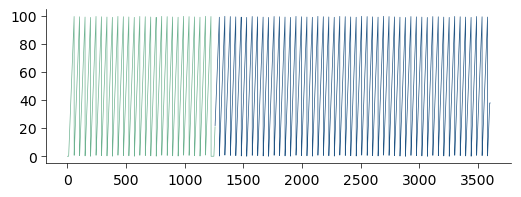

In [ ]:
fig = plt.figure(figsize=(6, 2))
ax = Clear_Axes(fig.add_subplot(111), close_spines = ['top', 'right'], ifxticks=True, ifyticks=True)
print(np.unique(trace['ms_map']), np.unique(trace['map']))
idx_m0 = np.where(trace['ms_map'] == 4)[0]
idx_m1 = np.where(trace['ms_map'] == 5)[0]
ax.plot(
    trace['ms_time'][idx_m0]/1000, 
    trace['ms_pos'][idx_m0], 
    linewidth=0.5, 
    color = sns.color_palette("crest", as_cmap=True)(0.2), 
    label="Map 0"
)
ax.plot(
    trace['ms_time'][idx_m1]/1000, 
    trace['ms_pos'][idx_m1], 
    linewidth=0.5, 
    color = sns.color_palette("crest", as_cmap=True)(0.8), 
    label="Map 1"
)
ax.set_yticks(np.linspace(0, 100, 6))
plt.savefig(os.path.join(loc, "Two alternative linear track LS.png"), dpi=300)
plt.savefig(os.path.join(loc, "Two alternative linear track LS.svg"), dpi=300)
plt.show()
